## Contents
- [Fully Connected Neural Networks](#Fully-Connected-Neural-Networks)
  - [Classification with Fashion MNIST](#Classification-with-Fashion-MNIST)
    - [Preprocessing](#Preprocessing)
    - [Building the model](#Building-the-model)
    - [Training the model](#Training-the-model)
    - [Batch Normalization](#Batch-Normalization)
    - [Dropout regularization](#Dropout-regularization)
    - [Learning Rate Scheduling](#Learning-Rate-Scheduling)
    - [Evaluating and predicting](#Evaluating-and-predicting)
    - [Saving and restoring a model](#Saving-and-restoring-a-model)
    - [Using callbacks during training](#Using-callbacks-during-training)
  - [Classification with hyperparameter tuning — Penguins](#Classification-with-hyperparameter-tuning)
  - [Regression with hyperparameter tuning — California housing](#Regression-with-hyperparameter-tuning)
- [Interpreting Neural Networks with SHAP](#Interpreting-Neural-Networks-with-SHAP)


# Fully Connected Neural Networks

There are several Python libraries for deep learning. The three most widely used are:

- **Keras** — a high-level API designed for readability and ease of use. As of Keras 3 (2024), it is **multi-backend**: it can run on TensorFlow, PyTorch, or JAX. This is the recommended starting point for most practitioners.
- **TensorFlow** — Google's production deep learning framework. 
- **PyTorch** — Meta's framework, dominant in academic research and increasingly in production. More flexible but lower-level than Keras.

We use **Keras with a TensorFlow backend**, as it is easier to use for beginners.

Install:
```
pip install keras tensorflow tensorboard keras-tuner 
```

Note that Keras with a TensorFlow backend cannot be installed or run in these situations:
Python version incompatibility

- Python 3.13 or newer — TensorFlow does not yet support it
- Python 3.8 or older — dropped from support in recent TensorFlow releases

Hardware

- Windows on ARM (Surface Pro X, Snapdragon laptops) 
- Apple Silicon (M1/M2/M3/M4) — standard pip install tensorflow fails; requires tensorflow-macos instead


If you have python incompatible version, you can create a conda environment with Python 3.11:
- `conda create -n ml2026p11 python=3.11`
- `conda activate ml2026p11` </br>
inside new ml2026p11 environment run:
-  `conda install ipykernel`
-  `python -m ipykernel install --user --name=ml2026p11`
now istall in the new environment: </br>
`pip install pandas matplotlib seaborn scikit-learn shap keras tensorflow tensorboard keras-tuner`
  
Easiest fallback — Google Colab:
- Go to colab.research.google.com, upload the .ipynb file, and run. TensorFlow, Keras, and a GPU are all pre-configured. The only cell to add at the top is:
`!pip install keras-tuner shap seaborn -q`


To enable GPU in Colab:

Runtime → Change runtime type → Hardware accelerator → T4 GPU → Save

 Keras places operations on GPU automatically when one is available.

You can check python version as follows:

In [ ]:
!python --version

To check your hardware:

In [ ]:
import platform
platform.machine()

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
from keras import Sequential, layers, initializers, regularizers, losses, callbacks, optimizers

print("TensorFlow:", tf.__version__)
print("Keras:     ", keras.__version__)

TensorFlow: 2.21.0
Keras:      3.14.0


## Classification with Fashion MNIST

**Fashion MNIST**: 70,000 greyscale images across 10 clothing categories, each 28×28 pixels. It is a standard benchmark — more challenging than handwritten digits while remaining fast to train on a laptop.

This is the same dataset structure discussed in the lecture: 784 input neurons (28×28 pixels flattened), 10 output neurons (one per class), hidden layers in between.

In [81]:
fashion_mnist = tf.keras.datasets.fashion_mnist
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print("Training images:", train_images.shape)
print("Test images:    ", test_images.shape)
print("Pixel range:    ", train_images.min(), "to", train_images.max())

Training images: (60000, 28, 28)
Test images:     (10000, 28, 28)
Pixel range:     0 to 255


Let's check class distribution

In [5]:
pd.Series(train_labels).value_counts()

9    6000
0    6000
3    6000
2    6000
7    6000
5    6000
1    6000
6    6000
4    6000
8    6000
Name: count, dtype: int64

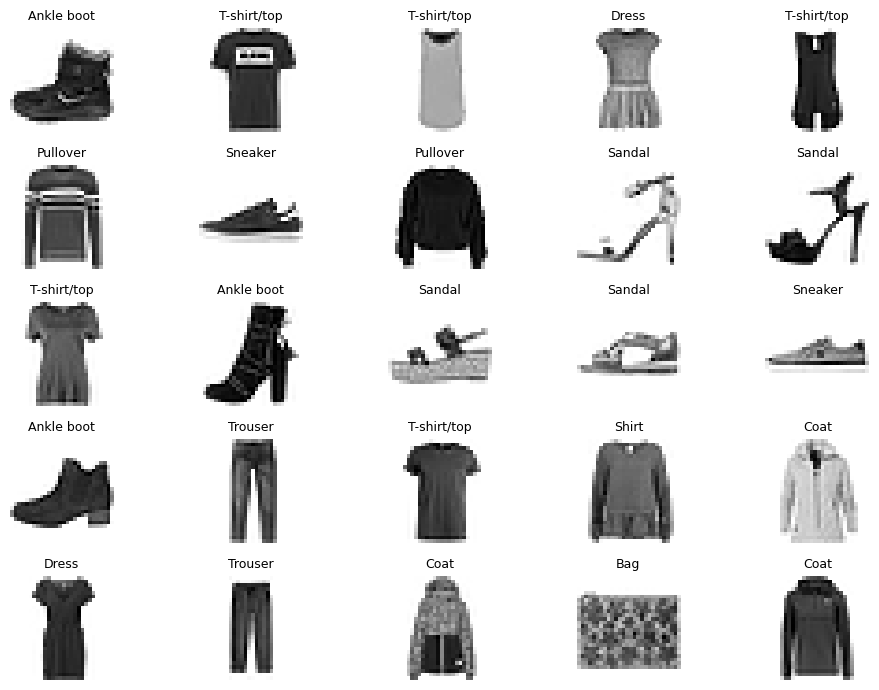

In [6]:
# Visualize a sample
fig, axes = plt.subplots(5, 5, figsize=(10, 7))
for i, ax in zip(range(25), axes.ravel()):
    ax.imshow(train_images[i], cmap=plt.cm.binary)
    ax.set_title(class_names[train_labels[i]], fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()

### Preprocessing

**Normalization**: raw pixel values range 0–255. We scale to [0, 1] by dividing by 255.

This is important because gradient descent is sensitive to input scale. Without normalization, large pixel values produce large gradients that dwarf the gradients from small pixel values, causing unstable training. The same transformation must be applied to all splits — but any statistics (mean, std for standardisation) must be fitted on the training set only.

**Naming convention**: we use `X_train`, `X_val`, `X_test` throughout for consistency. The test set is not touched until the very end.

In [82]:
train_images = train_images / 255.0
test_images  = test_images  / 255.0

X_test = test_images
y_test = test_labels

# 5,000 images for validation, remaining 55,000 for training
X_val,  X_train = train_images[:5000], train_images[5000:]
y_val,  y_train = train_labels[:5000], train_labels[5000:]

print(f"Train:      {X_train.shape[0]:,} images")
print(f"Validation: {X_val.shape[0]:,} images")
print(f"Test:       {X_test.shape[0]:,} images")

Train:      55,000 images
Validation: 5,000 images
Test:       10,000 images


### Building the model

A **Sequential** model is a linear stack of layers — output of each layer feeds the next. This is correct for the fully connected feedforward networks in the lecture. 

Architecture:
- **Input + Flatten**: reshapes 28×28 → 784-element vector
- **Dense(128, ReLU)**: 784×128 + 128 biases = 100,480 parameters
- **Dense(10, Softmax)**: 128×10 + 10 biases = 1,290 parameters

The input is a 28×28 pixel image — a 2D grid of 784 numbers. Flatten simply unrolls it into a single vector of 784 values, one per pixel. This is necessary because Dense layers expect a 1D input, not a 2D grid.
The first Dense layer connects every one of the 784 input values to every one of the 128 neurons.
The output layer connects every one of the 128 neurons to every one of the 10 output neurons. Softmax then converts the 10 raw scores into probabilities that sum to 1, and the digit with the highest probability is the prediction.

Before training begins, every weight in the network must be assigned a starting value. This matters more than it might seem: if weights start too large, activations explode through the layers and training diverges; if they start too small, activations shrink to near-zero and gradients vanish before reaching the early layers. Good initialization keeps the signal — both the forward activations and the backward gradients — at a stable magnitude throughout the network from the very first step.

**He initialization** (`HeNormal`) draws weights from a normal distribution with mean 0 and standard deviation $\sqrt{2/n}$ , where n is the number of inputs to that layer. ReLU sets all negative pre-activations to zero, which effectively kills roughly half of the signal passing through each layer. The surviving positive half carries all the variance forward, but because the negative half contributed nothing, the total variance of the layer's output is roughly half of what went in. The factor of 2 is the compensating key, offsetting the signal loss that ReLU introduces, and keeping activation and gradient magnitudes stable throughout the full depth of the network.

In [8]:
initializer = initializers.HeNormal(seed=0)

model = Sequential([
    layers.Input(shape=(28, 28)),
    layers.Flatten(),
    layers.Dense(128, activation='relu', kernel_initializer=initializer),
    layers.Dense(10,  activation='softmax', kernel_initializer=initializer)
])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# Inspect weight shapes of the first Dense layer
weights, biases = model.layers[1].get_weights()
print(f"Weight matrix shape: {weights.shape}  (784 inputs × 128 neurons)")
print(f"Bias vector shape:   {biases.shape}   (1 bias per neuron)")

Weight matrix shape: (784, 128)  (784 inputs × 128 neurons)
Bias vector shape:   (128,)   (1 bias per neuron)


### Compiling the model
After defining the model architecture, we compile the network. `model.compile()` does not train the network or touch the weights — it configures the three things the training loop needs before it can run:
- Optimizer — the algorithm that will update the weights after each batch. Here adam tells Keras to use Adam with its default learning rate of 0.001. This determines how weights are updated.
- Loss function — the function that measures how wrong the predictions are. Here `SparseCategoricalCrossentropy` is used as labels are integers (0–9). If labels were one-hot encoded, we would use `CategoricalCrossentropy` — the mathematics are identical.
- Metrics — what to track and report during training. Here accuracy is computed and printed after each epoch for both training and validation sets. Metrics do not affect training — they are purely for monitoring.


In [10]:
model.compile(
    optimizer='adam',                                  # Adam with lr=0.001 default
    loss=losses.SparseCategoricalCrossentropy(),       # for integer class labels
    metrics=['accuracy']
)

### Training the model

`model.fit()` runs the training loop. For each epoch it iterates through the training data in mini-batches (default batch size = 32), computes gradients via backpropagation, and updates all weights with Adam.

`validation_data=(X_val, y_val)` causes Keras to evaluate the model on the held-out set after each epoch — without updating weights on it. This gives us the train vs validation loss curves used to detect overfitting.

In [11]:
tf.random.set_seed(42)
np.random.seed(42)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    verbose=1
)

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.8210 - loss: 0.5061 - val_accuracy: 0.8600 - val_loss: 0.3915
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8629 - loss: 0.3781 - val_accuracy: 0.8734 - val_loss: 0.3549
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8770 - loss: 0.3379 - val_accuracy: 0.8786 - val_loss: 0.3400
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8853 - loss: 0.3124 - val_accuracy: 0.8828 - val_loss: 0.3295
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8916 - loss: 0.2926 - val_accuracy: 0.8794 - val_loss: 0.3286
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8974 - loss: 0.2774 - val_accuracy: 0.8840 - val_loss: 0.3246
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9017 - loss: 0.2635 - val_accuracy: 0.8818 - val_loss: 0.3310
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9063 - loss: 0.

Let's analyze the output:

- `Epoch 1/10` — this is the first of 10 epochs. One epoch means the model has seen every training example once.
- `1719/1719` — there are 1,719 mini-batches in one epoch. This comes from 55,000 training examples divided by the default batch size of 32: 55,000 ÷ 32 = 1,719 batches. The progress bar fills as each batch completes.
- `14s 6ms/step` — the epoch took 14 seconds in total, with each mini-batch taking approximately 6 milliseconds to process — forward pass, loss computation, backpropagation, and weight update.
- `accuracy: 0.8210` — the training accuracy averaged across all 1,719 batches during this epoch. As noted earlier, this is an underestimate of the model's true ability at the end of the epoch because it includes the early batches when the weights were still poor.
- `loss: 0.5061` — the training cross-entropy loss, also averaged across all batches during the epoch. Lower is better.
- `val_accuracy: 0.8600` — the accuracy on the 5,000 validation examples, evaluated once at the end of the epoch with the final weights. This is why it appears higher than training accuracy in early epochs — it is measured after all weight updates for that epoch are complete.
- `val_loss: 0.3915` — the validation loss, also evaluated once at the end of the epoch. Lower than training loss for the same reason.Sonnet 4.6Extended

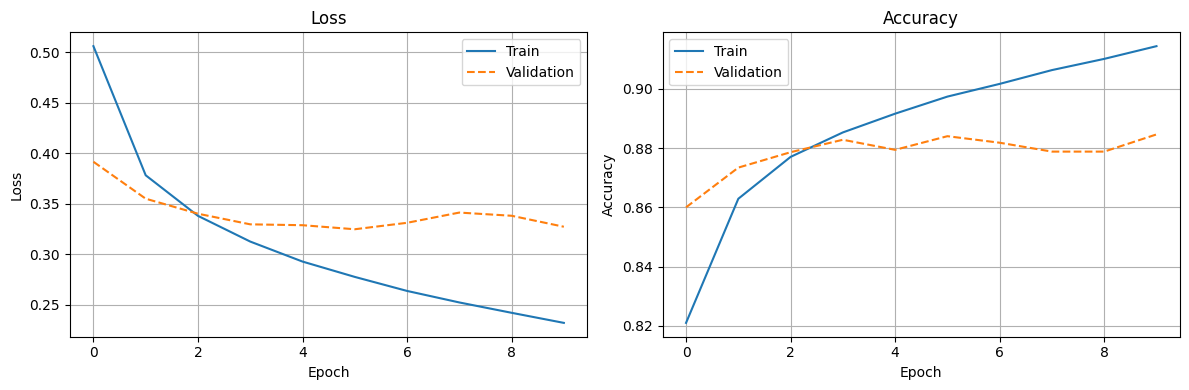

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'],     label='Train')
axes[0].plot(history.history['val_loss'], label='Validation', linestyle='--')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(True)

axes[1].plot(history.history['accuracy'],     label='Train')
axes[1].plot(history.history['val_accuracy'], label='Validation', linestyle='--')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.show()

**Reading the curves**: Both curves decrease together initially — the network is learning patterns that generalize. Training accuracy ends slightly above validation accuracy — this is expected. The model has seen training examples many times; validation examples are always new.

If validation loss plateaus and rises while training loss continues to fall — that is overfitting. We address that below.

Note that initially it seems counterintuitive to have validation perfroming better than training. This is beacuse training loss and accuracy are computed during the epoch — as the model is actively updating its weights. At the start of epoch 1, the weights are random and poor. The first few batches are trained on those poor weights, and their loss counts toward the epoch average. By the end of the epoch the weights are much better, but the early bad batches have already dragged the average down. So the training metric for epoch 1 is an average over a model that was getting progressively better throughout the epoch.
Validation loss and accuracy are computed after the epoch — in a single forward pass with the final weights from that epoch. By the time validation is evaluated, the model has already finished all its updates for that epoch and is at its best state for that epoch. This creates the illusion that validation is better than training early on. 

### Dropout regularization

**Dropout** randomly sets a fraction `p` of neuron outputs to zero during each training step. A fresh random mask is sampled for every mini-batch.

Three effects:
1. **Redundancy**: the network cannot rely on any single neuron, so it learns distributed representations.
2. **Ensemble approximation**: training with dropout is approximately equivalent to training and averaging 2ⁿ different sub-networks simultaneously.
3. **Inference scaling**: at inference time, dropout is disabled. All neurons are active. Keras automatically scales outputs by `1/(1−p)` to preserve expected activation magnitude.

Typical rates: 0.2–0.5. Use higher rates in early layers (more inputs to regularize) and lower rates close to the output.

In [15]:
initializer = initializers.HeNormal(seed=0)

model_drop = Sequential([
    layers.Input(shape=(28, 28)),
    layers.Flatten(),
    layers.Dense(256, activation='relu', kernel_initializer=initializer),
    layers.Dropout(0.3),                   # drop 30% of 256 neurons each training step
    layers.Dense(128, activation='relu', kernel_initializer=initializer),
    layers.Dropout(0.2),                   # smaller rate deeper in the network
    layers.Dense(10, activation='softmax')
])

model_drop.compile(optimizer='adam',
                   loss=losses.SparseCategoricalCrossentropy(),
                   metrics=['accuracy'])

tf.random.set_seed(42)
history_drop = model_drop.fit(X_train, y_train,
                               validation_data=(X_val, y_val),
                               epochs=15, verbose=0)

_, acc_drop = model_drop.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy with dropout: {acc_drop:.4f}")

Test accuracy with dropout: 0.8818


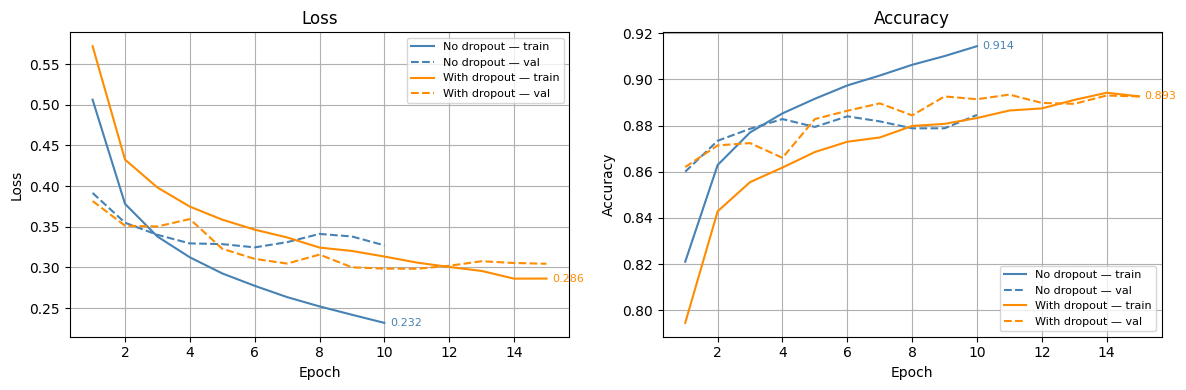

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for hist, label, col in [(history,      'No dropout',   'steelblue'),
                          (history_drop, 'With dropout', 'darkorange')]:
    tr_loss  = hist.history['loss']
    val_loss = hist.history['val_loss']
    tr_acc   = hist.history['accuracy']
    val_acc  = hist.history['val_accuracy']
    epochs   = range(1, len(tr_loss) + 1)

    axes[0].plot(epochs, tr_loss,  label=f'{label} — train', color=col)
    axes[0].plot(epochs, val_loss, label=f'{label} — val',   color=col, linestyle='--')
    axes[1].plot(epochs, tr_acc,   label=f'{label} — train', color=col)
    axes[1].plot(epochs, val_acc,  label=f'{label} — val',   color=col, linestyle='--')

    # Annotate final training value at the end of the last epoch
    axes[0].annotate(f'{tr_loss[-1]:.3f}',
                     xy=(epochs[-1], tr_loss[-1]),
                     xytext=(4, 0), textcoords='offset points',
                     fontsize=8, color=col, va='center')
    axes[1].annotate(f'{tr_acc[-1]:.3f}',
                     xy=(epochs[-1], tr_acc[-1]),
                     xytext=(4, 0), textcoords='offset points',
                     fontsize=8, color=col, va='center')

axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss'); axes[0].legend(fontsize=8); axes[0].grid(True)

axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy'); axes[1].legend(fontsize=8); axes[1].grid(True)

plt.tight_layout()
plt.show()

The train−val gap measures overfitting directly. Without dropout the gap widens as training continues — the model memorizes training examples. 

### Learning Rate Scheduling

Note that Adam works in two stages:

There is one global learning rate set by us. Adam then multiplies that global rate by a per-parameter scaling factor derived from each parameter's gradient history — the first and second moment estimates. This scaling happens internally and is never directly exposed.


Learning rate scheduling means varying the global learning rate over the course of training rather than keeping it fixed — typically starting larger to make fast progress early on and reducing it later so the optimizer converges precisely without overshooting the minimum. Even with Adam's per-parameter adaptation, explicit learning rate scheduling helps:

- **Early training**: a relatively high rate explores the loss landscape quickly.
- **Late training**: a smaller rate converges precisely without overshooting the minimum.

Two approaches demonstrated below:

**`ReduceLROnPlateau`** — reactive. Monitors `val_loss` and halves the learning rate when it stops improving for `patience` epochs. Good when training duration is unknown.


In [17]:
class LRLogger(callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        logs['lr'] = float(self.model.optimizer.learning_rate)
        
reduce_lr_cb = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,         # multiply lr by 0.5 on each plateau
    patience=3,
    min_lr=1e-6,
    verbose=1
)
lr_logger = LRLogger()
initializer = initializers.HeNormal(seed=0)
model_sched = Sequential([
    layers.Input(shape=(28, 28)),
    layers.Flatten(),
    layers.Dense(128, activation='relu', kernel_initializer=initializer),
    layers.Dropout(0.2),
    layers.Dense(10, activation='softmax')
])
model_sched.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),   # start high — schedule will reduce it
    loss=losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

tf.random.set_seed(42)
history_sched = model_sched.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    callbacks=[reduce_lr_cb, lr_logger],
    verbose=1
)

Epoch 1/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.8105 - loss: 0.5326 - val_accuracy: 0.8584 - val_loss: 0.3902 - learning_rate: 0.0010 - lr: 0.0010
Epoch 2/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8553 - loss: 0.3997 - val_accuracy: 0.8770 - val_loss: 0.3446 - learning_rate: 0.0010 - lr: 0.0010
Epoch 3/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8653 - loss: 0.3656 - val_accuracy: 0.8784 - val_loss: 0.3398 - learning_rate: 0.0010 - lr: 0.0010
Epoch 4/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8711 - loss: 0.3454 - val_accuracy: 0.8840 - val_loss: 0.3283 - learning_rate: 0.0010 - lr: 0.0010
Epoch 5/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8801 - loss: 0.3272 - val_accuracy: 0.8882 - val_loss: 0.3221 - learning_rate: 0.0010 - lr: 0.0010
Epoch 6/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8833 - loss: 0.3160 - val_accuracy: 0.8904 - val_loss: 0.3135 - learning_rate: 0.0010 - lr:

Next, let's train the same network with **Cosine decay**, which moothly decreases the rate following a cosine curve from initial to near-zero over a fixed number of steps. This is the standard schedule used to train all large language models (GPT, Claude, Gemini).

In [18]:
total_steps  = (len(X_train) // 32) * 15   # steps_per_epoch × n_epochs
cosine_decay = keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=0.001,
    decay_steps=total_steps
)
lr_logger = LRLogger()   
model_cos = Sequential([
    layers.Input(shape=(28, 28)),
    layers.Flatten(),
    layers.Dense(128, activation='relu',kernel_initializer=initializer),
    layers.Dropout(0.2),
    layers.Dense(10, activation='softmax')
])
model_cos.compile(
    optimizer=optimizers.Adam(learning_rate=cosine_decay),
    loss=losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

tf.random.set_seed(42)
history_cos = model_cos.fit(X_train, y_train,
                             validation_data=(X_val, y_val),
                            callbacks=[lr_logger], 
                             epochs=15, verbose=0)

_, acc_sched = model_sched.evaluate(X_test, y_test, verbose=0)
_, acc_cos   = model_cos.evaluate(X_test, y_test, verbose=0)
print(f"ReduceLROnPlateau test accuracy: {acc_sched:.4f}")
print(f"Cosine decay      test accuracy: {acc_cos:.4f}")

ReduceLROnPlateau test accuracy: 0.8941
Cosine decay      test accuracy: 0.8895


Now, let's visualize learning rate from both approaches. 

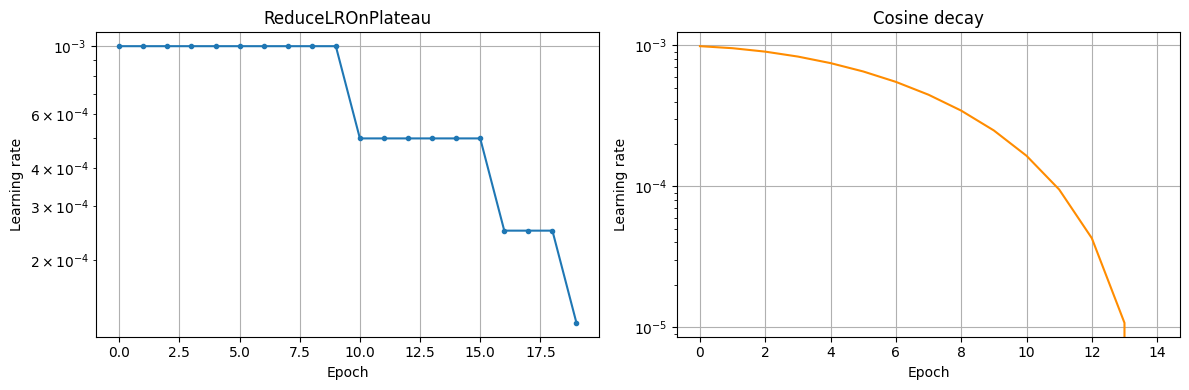

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_sched.history['lr'], label='ReduceLROnPlateau', marker='o', markersize=3)
axes[0].set_title('ReduceLROnPlateau'); axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Learning rate'); axes[0].set_yscale('log'); axes[0].grid(True)

axes[1].plot(history_cos.history['lr'], label='Cosine decay', color='darkorange')
axes[1].set_title('Cosine decay'); axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Learning rate'); axes[1].set_yscale('log'); axes[1].grid(True)

plt.tight_layout()
plt.show()

The two plots show the same starting learning rate of 0.001 but very different philosophies for how to reduce it.
`ReduceLROnPlateau` (left) holds the rate flat at 0.001 for the first few epochs because the validation loss was still improving — the callback had no reason to intervene. Once the loss stalled for 3 consecutive epochs, triggering a halving to 0.0005. The shape is a staircase — flat, then sharp drop, then flat again. The schedule is reactive: it responds to what actually happens during training rather than following a predetermined plan.
Cosine decay (right) begins reducing immediately from epoch 0, following a smooth curve that accelerates toward zero as training ends. By epoch 13 the rate has dropped from 0.001 to approximately 0.00001 — a 100× reduction. The shape is predetermined: the full decay curve is fixed before training begins based on the total number of steps. `ReduceLROnPlateau` wastes no learning rate budget early when the model is still improving rapidly, but it only ever reduces once per plateau detection — it cannot anticipate when reduction will be needed. Cosine decay starts reducing immediately which may slow early convergence, but it guarantees the optimizer is taking very small, precise steps in the final epochs regardless of whether a plateau was detected. This predictability is why cosine decay became the standard for training large language models where training runs are planned in advance and monitored less interactively.

### Evaluating and predicting

We will now use the dropout model to illustrate evaluation. `model.evaluate()` runs a single forward pass through the entire dataset we pass to it and returns the loss and any metrics we specified at compile time. Note that we specified accuracy.

In [20]:
test_loss, test_acc = model_drop.evaluate(X_test, y_test, verbose=2)
print(f"\nTest accuracy: {test_acc:.4f}")
print(f"Test loss:     {test_loss:.4f}")

313/313 - 1s - 4ms/step - accuracy: 0.8818 - loss: 0.3436

Test accuracy: 0.8818
Test loss:     0.3436


Unlike `sklearn`, `model.predict()` in Keras returns class **probabilities** (the Softmax output), not class labels.  A prediction is now an array of 10 probabilities that the image corresponds to each of the 10 different articles of clothing. We can see which label has the highest probability using `np.argmax`. Let's check the prediction for the first instance in the test dataset.

In [21]:
y_pred_proba = model_drop.predict(X_test, verbose=0)

i = 0
print(f"Probability vector: {np.round(y_pred_proba[i], 3)}")
print(f"Predicted: {class_names[np.argmax(y_pred_proba[i])]}  (confidence {np.max(y_pred_proba[i]):.1%})")
print(f"True:      {class_names[y_test[i]]}")

Probability vector: [0.    0.    0.    0.    0.    0.002 0.    0.001 0.    0.998]
Predicted: Ankle boot  (confidence 99.8%)
True:      Ankle boot


So, the model is most confident that this image is an ankle boot, or class_names[9]. Examining the test label shows that this classification is correct:

In [22]:
test_labels[0]

np.uint8(9)

Next, we will use the function below to view the predictions. When predicted and true label match we will plot in blue, and in red, when they are different.

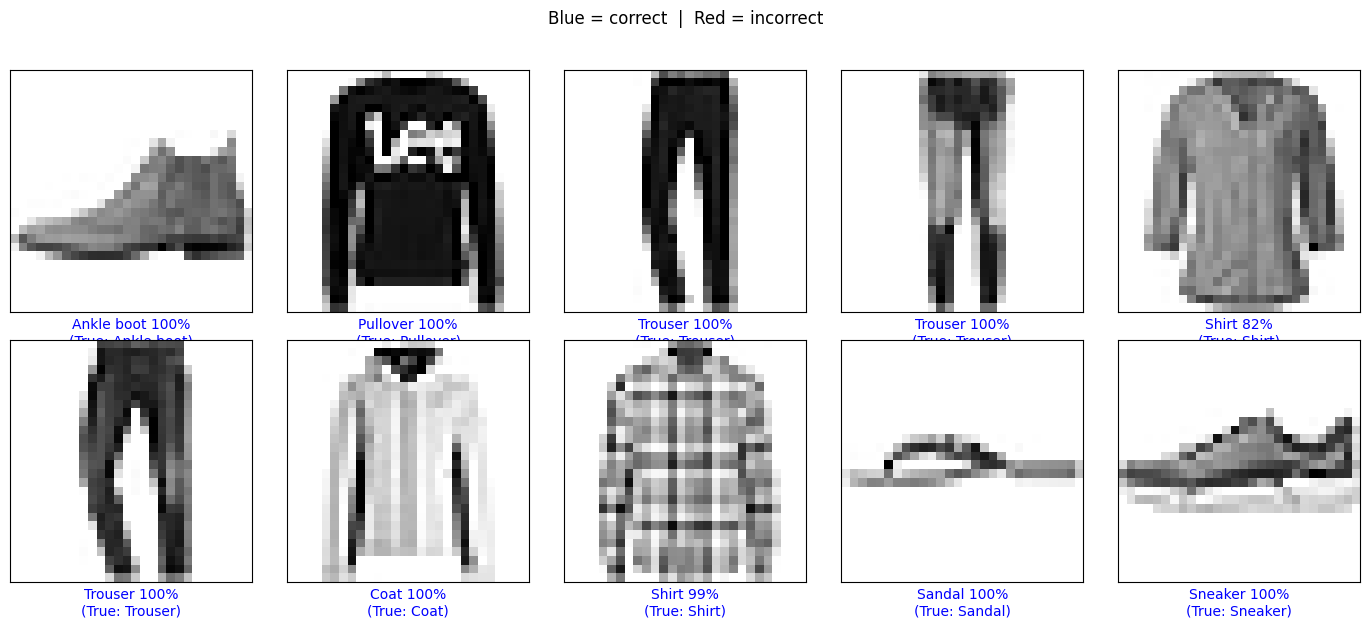

In [23]:
def plot_prediction(i, preds, true_labels, imgs):
    pred_class, true_class = np.argmax(preds), true_labels[i]
    color = 'blue' if pred_class == true_class else 'red'
    plt.imshow(imgs[i], cmap=plt.cm.binary)
    plt.xlabel(f"{class_names[pred_class]} {100*np.max(preds):.0f}%\n(True: {class_names[true_class]})",
               color=color)
    plt.xticks([]); plt.yticks([])

fig = plt.figure(figsize=(14, 6))
for idx, i in enumerate(range(10)):
    plt.subplot(2, 5, idx+1)
    plot_prediction(i, y_pred_proba[i], y_test, X_test)
plt.suptitle('Blue = correct  |  Red = incorrect', y=1.02, fontsize=12)
plt.tight_layout(); plt.show()

### Saving and restoring a model

Keras saves models in the `.keras` format (recommended since Keras 3) — a single file bundling architecture, weights, and compile settings. 

In [24]:
model_drop.save("fashion_mnist_model.keras")
print("Saved.")

model_loaded = keras.models.load_model("fashion_mnist_model.keras")
_, loaded_acc = model_loaded.evaluate(X_test, y_test, verbose=0)
print(f"Loaded model test accuracy: {loaded_acc:.4f}")

Saved.
Loaded model test accuracy: 0.8818


### Using callbacks during training

Two callbacks should be used together in every production training run:

**`ModelCheckpoint(save_best_only=True)`** saves the model to disk only when `val_loss` improves. Ensures we always have the best model on disk even if training later degrades.

**`EarlyStopping(restore_best_weights=True)`** stops training when validation loss has not improved for `patience` consecutive epochs, then restores weights from the best epoch. We should set `epochs` very large and let early stopping decide when to stop — this eliminates the need to guess the right epoch count.

In [25]:
initializer = initializers.HeNormal(seed=0)
model_cb = Sequential([
    layers.Input(shape=(28, 28)),
    layers.Flatten(),
    layers.Dense(128, activation='relu', kernel_initializer=initializer),
    layers.Dropout(0.2),
    layers.Dense(10, activation='softmax')
])
model_cb.compile(optimizer='adam',
                 loss=losses.SparseCategoricalCrossentropy(),
                 metrics=['accuracy'])

checkpoint_cb     = callbacks.ModelCheckpoint("best_model.keras", save_best_only=True)
early_stopping_cb = callbacks.EarlyStopping(patience=10, restore_best_weights=True, verbose=1)

tf.random.set_seed(42)
history_cb = model_cb.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,          # large upper bound — early stopping will determine the actual number
    callbacks=[checkpoint_cb, early_stopping_cb],
    verbose=1
)

_, acc_cb = model_cb.evaluate(X_test, y_test, verbose=0)
print(f"\nStopped at epoch {len(history_cb.history['loss'])}")
print(f"Test accuracy: {acc_cb:.4f}")

Epoch 1/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8085 - loss: 0.5412 - val_accuracy: 0.8602 - val_loss: 0.3996
Epoch 2/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8541 - loss: 0.4025 - val_accuracy: 0.8700 - val_loss: 0.3617
Epoch 3/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8640 - loss: 0.3714 - val_accuracy: 0.8758 - val_loss: 0.3469
Epoch 4/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8720 - loss: 0.3480 - val_accuracy: 0.8842 - val_loss: 0.3317
Epoch 5/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8793 - loss: 0.3310 - val_accuracy: 0.8816 - val_loss: 0.3260
Epoch 6/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8831 - loss: 0.3177 - val_accuracy: 0.8866 - val_loss: 0.3238
Epoch 7/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8855 - loss: 0.3064 - val_accuracy: 0.8896 - val_loss: 0.3085
Epoch 8/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8888 - 

## Classification with hyperparameter tuning — Penguins

We use the **Palmer Penguins** dataset (3 species, ~344 rows, 5 features) to demonstrate Keras Tuner. We load it from `seaborn`.

Note: for a dataset this small, a gradient-boosted tree would typically outperform a neural network. **We also use too complex network for such a small dataset**, but this example is purely to illustrate the tuning workflow in acceptable time.

Alternative: `Optuna` is widely used in production as a model-agnostic hyperparameter tuning library with better Bayesian optimisation support. Keras Tuner is convenient when already in the Keras ecosystem.

In [26]:
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

df = sns.load_dataset('penguins').dropna(subset=['species'])
print(df.shape)
df.head()

(344, 7)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


Next, we will impute the numerical missing values with mean, and we will use mode for categorical. We will use one hot encoding for the feature island, and scale the numerical features. We will use ColumnTransformer and Pipeline. Note that if we did not want to preprocess some columns, we would need to set ColumnTransformer's parameter remainder to passthrough. By default, only the specified columns in transformers are transformed and combined in the output, and the non-specified columns are dropped.

Our target value is species. We will use LabelEncoder to encode target labels with value between 0 and n_classes-1.

In [27]:
y = df['species']
X = df.drop(columns=['species', 'sex'])

X_train_val, X_test,  y_train_val, y_test  = train_test_split(X, y, test_size=0.1, random_state=0)
X_train,     X_val,   y_train,     y_val   = train_test_split(X_train_val, y_train_val,
                                                                test_size=0.1, random_state=0)

numerical = df.select_dtypes(include=['float64', 'int64']).columns

num_pipe = Pipeline([('imputer', SimpleImputer(strategy='mean')),
                     ('scaler',  StandardScaler())])
cat_pipe = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                     ('onehot',  OneHotEncoder(handle_unknown='ignore'))])

preprocessor = ColumnTransformer([
    ('num', num_pipe, numerical),
    ('cat', cat_pipe, ['island'])
])

X_train = preprocessor.fit_transform(X_train)    
X_val   = preprocessor.transform(X_val)
X_test  = preprocessor.transform(X_test)

label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train)
y_val   = label_encoder.transform(y_val)
y_test  = label_encoder.transform(y_test)

print(f"Input features: {X_train.shape[1]}  (4 numeric + 3 one-hot island dummy variables)")
print(f"Classes: {label_encoder.classes_}")

Input features: 7  (4 numeric + 3 one-hot island dummy variables)
Classes: ['Adelie' 'Chinstrap' 'Gentoo']


#### Keras Tuner

We define a `build_model(hp)` function where `hp` is the hyperparameter object. `hp.Int(...)`, `hp.Choice(...)`, and `hp.Float(...)` define the search space for each hyperparameter. The tuner calls this function with different values across trials.

In [28]:
import keras_tuner as kt

def build_model(hp):
    model = keras.Sequential([
        layers.Input(shape=(X_train.shape[1],), name='Input_Layer'),
        layers.Dense(
            units=hp.Int('units1', min_value=4, max_value=32, step=4),
            activation=hp.Choice('activation1', values=['relu', 'tanh'])
        ),
        layers.Dense(
            units=hp.Int('units2', min_value=4, max_value=16, step=4),
            activation=hp.Choice('activation2', values=['relu', 'tanh'])
        ),
        layers.Dense(3, activation='softmax')   # 3 output neurons = 3 species
    ])
    model.compile(
        optimizer=optimizers.Adam(
            learning_rate=hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
        ),
        loss=losses.SparseCategoricalCrossentropy(),
        metrics=['accuracy']
    )
    return model

First, some general notes about the input and the output layer, which are not tuned. Generally, all layers in Keras need to know the shape of their inputs in order to be able to create their weights. It creates its weights the first time it is called on an input, since the shape of the weights depends on the shape of the inputs. When we instantiate a Sequential model without an input shape, it isn't "built": it has no weights (and calling *model.weights* results in an error stating just this). The weights are created when the model first sees some input data. Alternatively, we can start the model by passing an Input object, just as we did above, so that it knows its input shape from the start. But, even if we omitted the Input object, the code would execute, as it would learn the input shape once it sees the data.

Since we have three classes, our output layer has 3 neurons, and we will use softmax activation function.

The `build_model` function above is the model builder function that creates, compiles, and returns a neural network model.

The parameter to the build_model function `hp` is passed internally by the Keras tuner. The argument `hp` is an instance of the class HyperParameters.

To define a hyperparameter, we can use the method `hp.Int`. The first value in  `hp.Int` denotes the name for that hyper-parameter, in our case, it is "units1". The min_value argument denotes the minimum value for the hyper-parameter to take and the max_value argument denotes the maximum value for the hyper-parameter to take. The steps argument denotes how many steps to take from min_value to max_value.  

The Int method is defined for the first two layers of the neural network model with the names "units1" and "units2".

The first argument of the method `hp.Choice` denotes the name for that hyper-parameter as said earlier. The values argument of the method denotes the choice to make among those values. The Choice method is defined to select the type of the activation function in two layers, and the learning rate for the loss function optimizer, Adam.
After defining the hyper-parameters we compile the model.

We are now ready to start searching for the best hyperparameter values.

First, let's instantiate the tuner. Here we are using the RandomSearch strategy. Keras Tuner also supports BayesianOptimization, Hyperband, and Sklearn.

The way the tuner will determine the best model is by looking at the validation accuracy and we are going to be running 10 trials.

In [29]:
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=10,             # 10 is enough for a teaching example; use 50–100 in production
    directory='keras_tuner',
    project_name='penguin_classification',
    overwrite=True
)


The parameter *overwrite* control whether to overwrite the previous results in the same directory or resume the previous search instead. Here we set *overwrite=True* to start a new search and ignore any previous results, but if we would like to save the results to be able to resume afterwards, we would set it to *overwrite=False*.

A path to a directory for storing the search results is specified with *directory* and *project_name* is the name of the sub-directory in the directory.

We can print out the summary of the search options:

In [30]:
tuner.search_space_summary()

Search space summary
Default search space size: 5
units1 (Int)
{'default': None, 'conditions': [], 'min_value': 4, 'max_value': 32, 'step': 4, 'sampling': 'linear'}
activation1 (Choice)
{'default': 'relu', 'conditions': [], 'values': ['relu', 'tanh'], 'ordered': False}
units2 (Int)
{'default': None, 'conditions': [], 'min_value': 4, 'max_value': 16, 'step': 4, 'sampling': 'linear'}
activation2 (Choice)
{'default': 'relu', 'conditions': [], 'values': ['relu', 'tanh'], 'ordered': False}
learning_rate (Choice)
{'default': 0.01, 'conditions': [], 'values': [0.01, 0.001, 0.0001], 'ordered': True}


Now we are ready to search for the best parameters. We will use validation data to monitor the model's performance.

In [31]:
tuner.search(X_train, y_train, epochs=20, validation_data=(X_val, y_val), verbose=0)

best_model is a model with the best architecture and hyperparameters, but weights are random since it is a freshly initialized model that has yet to learn from the data; as such, it must be fit to the training set.

In [32]:
best_hps   = tuner.get_best_hyperparameters(num_trials=1)[0]
best_model = tuner.hypermodel.build(best_hps)

# best_model has the best architecture but random weights — must be trained from scratch
best_model.fit(X_train, y_train, epochs=30,
               validation_data=(X_val, y_val), verbose=0)


During the search, the model-building function is called with different hyperparameter values in different trial. In each trial, the tuner would generate a new set of hyperparameter values to build the model. The model is then fit and evaluated. The metrics are recorded. The tuner progressively explores the space and finally finds a good set of hyperparameter values.

We can check what are the best parameters by checking the best trial:

In [33]:
tuner.oracle.get_best_trials(num_trials=1)[0].hyperparameters.values

{'units1': 32,
 'activation1': 'relu',
 'units2': 8,
 'activation2': 'relu',
 'learning_rate': 0.01}

Let's visualize our best model:

In [34]:
best_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                      │ (None, 32)                  │             256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 8)                   │             264 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 3)                   │              27 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,643 (6.42 KB)

 Trainable params: 547 (2.14 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,096 (4.29 KB)

Note that the Input object is not displayed as part of model.layers, since it isn't a layer.

We can also look at the tuning results:

In [35]:
tuner.results_summary()

Results summary
Results in keras_tuner\penguin_classification
Showing 10 best trials
Objective(name="val_accuracy", direction="max")

Trial 00 summary
Hyperparameters:
units1: 32
activation1: relu
units2: 8
activation2: relu
learning_rate: 0.01
Score: 1.0

Trial 04 summary
Hyperparameters:
units1: 8
activation1: tanh
units2: 4
activation2: tanh
learning_rate: 0.001
Score: 1.0

Trial 05 summary
Hyperparameters:
units1: 12
activation1: tanh
units2: 16
activation2: tanh
learning_rate: 0.01
Score: 1.0

Trial 06 summary
Hyperparameters:
units1: 16
activation1: relu
units2: 16
activation2: relu
learning_rate: 0.001
Score: 1.0

Trial 07 summary
Hyperparameters:
units1: 32
activation1: tanh
units2: 8
activation2: tanh
learning_rate: 0.01
Score: 1.0

Trial 09 summary
Hyperparameters:
units1: 20
activation1: tanh
units2: 16
activation2: tanh
learning_rate: 0.001
Score: 1.0

Trial 01 summary
Hyperparameters:
units1: 4
activation1: relu
units2: 16
activation2: relu
learning_rate: 0.001
Score: 0.96

We can evaluate our model on the test set:

In [36]:
test_loss, test_acc = best_model.evaluate(X_test,  y_test)

print('Test accuracy:', test_acc)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 1.0000 - loss: 0.0056
Test accuracy: 1.0


We can also also print out the classification report from `sklearn`. Note that with `predict` we get the probabilities, then we pick the class with the highest probability with *np.argmax(y_pred, axis=1)*. Note that *axis=1* means that we find the maximum across columns:

In [37]:
from sklearn.metrics import classification_report

y_pred = best_model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
print(classification_report(y_test, y_pred_classes))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00        13

    accuracy                           1.00        35
   macro avg       1.00      1.00      1.00        35
weighted avg       1.00      1.00      1.00        35



This was a very simple dataset, hence our performance is quite good.

## Regression with hyperparameter tuning — California housing

Regression differs from classification in three ways:
- **Output layer**: 1 neuron with **linear activation** — the output is unbounded
- **Loss function**: `MeanSquaredError`
- **Evaluation**: we report **RMSE** (root MSE) because it is in the same units as the target (house prices in $100k), making it interpretable

We also tune **number of hidden layers** (`hp.Int('num_layers', ...)`), which directly illustrates the lecture point that depth vs width is a design decision that can be optimised empirically.

In [38]:
from sklearn.datasets import fetch_california_housing

cal_housing = fetch_california_housing()
X = pd.DataFrame(cal_housing.data, columns=cal_housing.feature_names)
y = cal_housing.target

X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.1, random_state=0)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val,
                                                    test_size=0.3, random_state=0)

We will scale the dataset, by doing the fit and transform on the train, and transform on the validation and test data:

In [39]:
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Train: (13003, 8), Val: (5573, 8), Test: (2064, 8)


We will again use keras tuner to tune our network. This time we will not only tune the number of nodes in the hidden layers, but also number of layers, from 1 to 4 (the parameters passed to hp.Int are the name of the parameter, the minimum and the maximum value):

In [40]:
def build_regression_model(hp):
    model = Sequential([layers.Input(shape=(X_train.shape[1],))])
    for i in range(hp.Int('num_layers', min_value=1, max_value=4)):
        model.add(layers.Dense(
            units=hp.Int(f'units_{i}', min_value=32, max_value=256, step=32),
            activation='relu',
            kernel_regularizer=regularizers.l2(0.001)     # L2 weight decay
        ))

    model.add(layers.Dense(1, activation='linear'))        # regression output: single neuron, no bounds

    model.compile(
        optimizer=optimizers.Adam(
            learning_rate=hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
        ),
        loss=losses.MeanSquaredError(),
        metrics=['mean_squared_error']
    )
    return model

We used a loop with `hp.Int` to define that we are testing 1 to 4 total number of hidden layers. For each hidden layer we are testing for the number of nodes, from 32 to 256.

Additionally here we have introduced another technique for preventing overfitting: L2 regularization. With this we put constraints on the complexity of a network by forcing its weights only to take small values, which makes the distribution of weight values more "regular". This is called "weight regularization", and it is done by adding to the loss function of the network a cost associated with having large weights. In keras, weight regularization is added by passing weight regularizer instances to layers as keyword arguments. We have added L2 weight regularization with regularization strength 0.001, meaning that every coefficient in the weight matrix of the layer will add 0.001 * weight_coefficient_value$^2$ to the total loss of the network.

This time, we will not use `RandomSearch`, instead we will use `Hyperband`. This is an optimized version of random search which uses early-stopping to speed up the hyperparameter tuning process. The main idea is to fit a large number of models for a small number of epochs and to only continue training for the models achieving the highest accuracy on the validation set. The *max_epochs* variable is the max number of epochs that a model can be trained for. 

In [41]:
# Hyperband uses early-stopping internally to discard poor trials quickly
# More efficient than RandomSearch for regression tasks with many hyperparameters
tuner_reg = kt.Hyperband(
    build_regression_model,
    objective='val_mean_squared_error',
    max_epochs=15,
    overwrite=True,
    directory='keras_tuner',
    project_name='california_regression'
)


Previously we have used "val_accuracy" as the objective metric, but there are many built-in metrics we can use. Here is a list of the built-in metrics: https://keras.io/api/metrics/

The most commonly used metric is *val_loss*, which is the validation loss.

To use a built-in metric as the objective, we need to follow to first compile the model with that metric. The name string of the objective is always in the format of f"val_{metric_name_string}". For example, the objective name string of mean squared error evaluated on the validation data should be "val_mean_squared_error".

Note that since we put regularization, that means that our cost function includes the penalty term. Hence, when doing this, we should not use *val_loss* as our objective, as it includes the regularization term.

In [42]:
tuner_reg.search_space_summary()

Search space summary
Default search space size: 3
num_layers (Int)
{'default': None, 'conditions': [], 'min_value': 1, 'max_value': 4, 'step': 1, 'sampling': 'linear'}
units_0 (Int)
{'default': None, 'conditions': [], 'min_value': 32, 'max_value': 256, 'step': 32, 'sampling': 'linear'}
learning_rate (Choice)
{'default': 0.01, 'conditions': [], 'values': [0.01, 0.001, 0.0001], 'ordered': True}


The primary benefit of using a dedicated output directory for each experiment is that we can start, stop, and resume hyperparameter tuning experiments. This is especially important since hyperparameter tuning can take a considerable amount of time. Given that here we are testing many different combinations, the search will take some time:

In [43]:
tuner_reg.search(X_train, y_train, epochs=10, validation_data=(X_val, y_val))

Trial 30 Complete [00h 00m 52s]
val_mean_squared_error: 0.3466111421585083

Best val_mean_squared_error So Far: 0.32299160957336426
Total elapsed time: 00h 08m 47s


In [44]:
best_hps = tuner_reg.get_best_hyperparameters(num_trials=1)[0]
best_model_reg = tuner_reg.hypermodel.build(best_hps) 
best_model_reg.fit(X_train, y_train, epochs=10, validation_data=(X_val, y_val))

Epoch 1/10
407/407 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.8677 - mean_squared_error: 0.6011 - val_loss: 0.6163 - val_mean_squared_error: 0.4111
Epoch 2/10
407/407 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.5442 - mean_squared_error: 0.3712 - val_loss: 0.5376 - val_mean_squared_error: 0.3898
Epoch 3/10
407/407 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.4826 - mean_squared_error: 0.3524 - val_loss: 0.4918 - val_mean_squared_error: 0.3759
Epoch 4/10
407/407 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.4407 - mean_squared_error: 0.3365 - val_loss: 0.4535 - val_mean_squared_error: 0.3586
Epoch 5/10
407/407 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.4104 - mean_squared_error: 0.3235 - val_loss: 0.4258 - val_mean_squared_error: 0.3456
Epoch 6/10
407/407 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.4062 - mean_squared_error: 0.3307 - val_loss: 0.4184 - val_mean_squared_error: 0.3465
Epoch 7/10
407/407 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.3764 - mean_squared_error: 0.3090 - val_loss: 0.40

Let's see the best parameters:

In [45]:
tuner_reg.oracle.get_best_trials(num_trials=1)[0].hyperparameters.values

{'num_layers': 4,
 'units_0': 192,
 'learning_rate': 0.001,
 'units_1': 128,
 'units_2': 192,
 'tuner/epochs': 15,
 'tuner/initial_epoch': 5,
 'tuner/bracket': 2,
 'tuner/round': 2,
 'units_3': 32,
 'tuner/trial_id': '0012'}

In [46]:
best_model_reg.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                      │ (None, 192)                 │           1,728 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 128)                 │          24,704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 192)                 │          24,768 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 32)                  │           6,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 172,229 (672.77 KB)

 Trainable params: 57,409 (224.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 114,820 (448.52 KB)

Now we can evaluate the best model on the test set:

In [47]:
test_loss, test_mse = best_model_reg.evaluate(X_test,  y_test)
print('Test MSE:', test_mse)

65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3496 - mean_squared_error: 0.3006
Test MSE: 0.3006265461444855


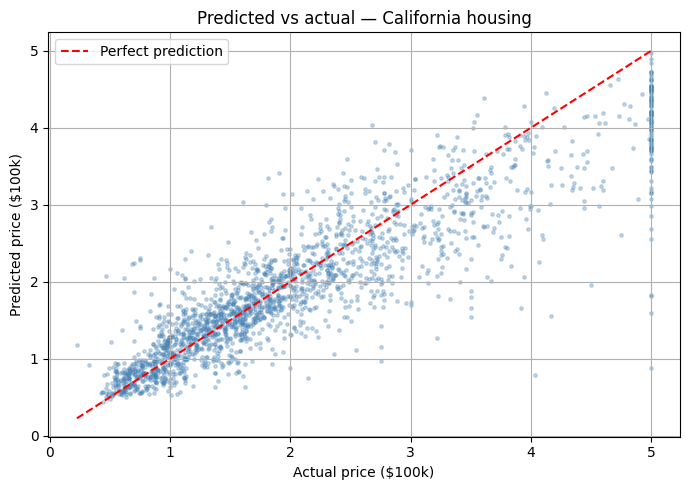

In [48]:
y_pred_reg = best_model_reg.predict(X_test, verbose=0).flatten()

plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred_reg, alpha=0.3, s=6, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         'r--', linewidth=1.5, label='Perfect prediction')
plt.xlabel('Actual price ($100k)'); plt.ylabel('Predicted price ($100k)')
plt.title('Predicted vs actual — California housing')
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

## Interpreting Neural Networks with SHAP

Neural networks are often called "black boxes" — they achieve high accuracy but provide no natural explanation for individual predictions. We will again resort to SHAP for interpretability.


We use the `California housing model` trained above — feature importance is more interpretable for house prices than clothing categories.

`shap.GradientExplainer` is the recommended explainer for Keras/TensorFlow models. It uses integrated gradients (backpropagation through the network) to efficiently approximate SHAP values. However, SHAP values from GradientExplainer are approximate. For exact Shapley values, we should use shap.KernelExplainer — but it is substantially slower. 

In [76]:
import shap
warnings.filterwarnings('ignore', category=UserWarning)

In [77]:
# Background dataset: 200 training examples used as the baseline
# SHAP values measure deviation from the mean prediction over this background
background = X_train[:200]

explainer = shap.GradientExplainer(best_model_reg, background)

In [78]:
# Compute SHAP values for 200 test examples
# Output shape: (n_samples, n_features)
shap_values = explainer.shap_values(X_test[:200])

if shap_values.ndim == 3:
    shap_values = shap_values[:, :, 0]
shap_values.shape

(200, 8)

The shape above means means 200 samples, 8 features.

With summary plot we can see ranked features by mean absolute SHAP value. Each dot = one test example. X-axis = SHAP value (impact on prediction). Colour = feature value (red = high, blue = low).


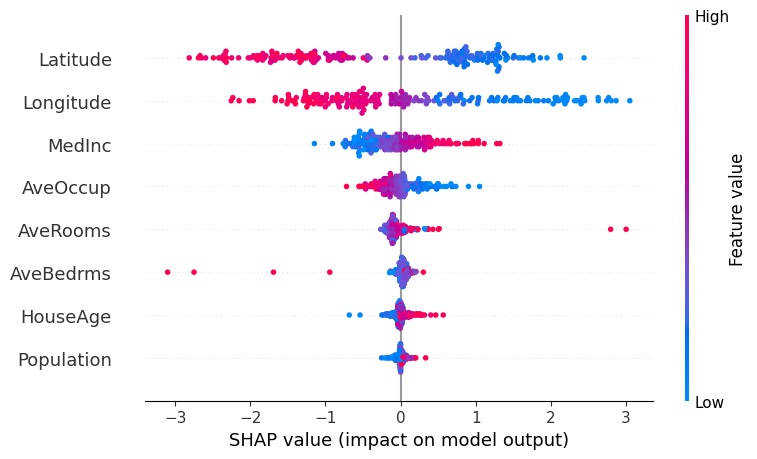

In [79]:
shap.summary_plot(
    shap_values,
    X_test[:200],
    feature_names=cal_housing.feature_names,
    plot_type='dot',
    rng=np.random.default_rng(42)
)

The plot shows the SHAP values for all 8 features across 200 test examples. Each dot is one example, positioned on the x-axis by how much that feature pushed the prediction away from the baseline. The colour shows the feature value — red is high, blue is low.
Latitude and Longitude dominate — they have the widest spread of SHAP values, ranging from −3.5 to +3. This means geography is the single strongest driver of predicted house prices in this model, which makes intuitive sense for California where coastal areas (specific latitude/longitude combinations) command dramatically higher prices than inland areas. Notice that for both features, high values (red) tend to push predictions in one direction and low values (blue) in the other.

A waterfall plot explains one specific prediction. It shows which features pushed the output higher (red) and which pushed it lower (blue), starting from the baseline and arriving at the final prediction.

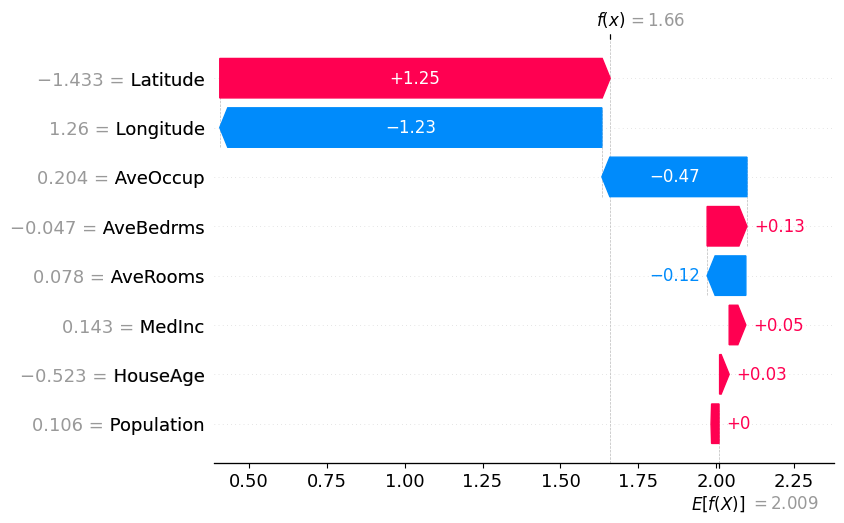

In [80]:
baseline = float(best_model_reg.predict(background, verbose=0).mean())
shap_explanation = explainer(X_test[:200])
shap_values_arr = np.squeeze(shap_explanation.values)  # (200, 8)

shap_exp = shap.Explanation(
    values        = shap_values_arr[0],
    base_values   = baseline,
    data          = X_test[0],
    feature_names = list(cal_housing.feature_names)
)
shap.plots.waterfall(shap_exp)

From the plot, we see that the model starts at the baseline (E[f(x)]). Each row shows one feature's contribution. The features sum to the final prediction. Red pushes up, blue pushes down. 

## Key points

Keras model building

- Build: `model = Sequential(...)`
- Compile: `model.compile(optimizer='adam', loss=..., metrics=[ ...])`
- Train: `history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=...)`
- Evaluate: `test_loss, test_acc = model.evaluate(X_test, y_test)`
- Predict: `y_pred_proba = model.predict(X_test) then y_pred_classes = np.argmax(y_pred_proba, axis=1)`
- Save/load:` model.save("model.keras") and keras.models.load_model("model.keras")`

Dropout

- Add after activation: `layers.Dropout(0.3)` — active during training, disabled at inference automatically

Learning rate scheduling

- Reactive: `callbacks.ReduceLROnPlateau(monitor=..., factor=..., patience=...)`
- Planned: `keras.optimizers.schedules.CosineDecay(initial_learning_rate=0.001, decay_steps=total_steps)`
Log lr each epoch with a custom callback and read via `history.history['lr']`

Callbacks

- Save best: `callbacks.ModelCheckpoint("model.keras", save_best_only=True)`
- Stop early: `callbacks.EarlyStopping(patience=..., restore_best_weights=True)`
- Pass both: `model.fit(..., callbacks=[checkpoint_cb, early_stopping_cb])`

Keras Tuner

- Define search space inside build_model(hp) using `hp.Int(...)`, `hp.Choice(...)`, `hp.Float(...)`
- Run search: `tuner.search(X_train, y_train, epochs=... validation_data=(X_val, y_val))`
- Retrieve best: `best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]` then `best_model = tuner.hypermodel.build(best_hps)`
- RandomSearch: `kt.RandomSearch()`
- Hyperband: `kt.Hyperband()`

SHAP for neural networks

- Explainer: `explainer = shap.GradientExplainer(model, background_data)`
- Compute values: `shap_values = explainer.shap_values(X_test[:200])`
- Global importance: `shap.summary_plot(shap_values, X_test[:200], feature_names=feature_names)`
- Single prediction: `shap.plots.waterfall(shap.Explanation(values=shap_values[i], base_values=baseline, data=X_test[i], feature_names=feature_names))`
